#### Midterm 2
- Chris O

In [1]:
# general libraries
import cvxpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# libraries for question 1
from scipy.differentiate import hessian

# libraries for Question 3
import json # import api key
import requests # obtain stock price data from financial data API (free)
from datetime import datetime, date



#### Question 1 [ Steepest Descent Algorithm ]
- Reference: Section 9.2-9.4 [Gradient Descent, Convergence, and Line Search/Backtracking]

In [353]:
x0 = np.array([1, 1, 1]).reshape(-1,1)
print(f"{x0}")
t = 0.01 # step size
eps = 1e-6

[[1]
 [1]
 [1]]


In [354]:
def f(x):
    return (x[0] + 5)**2 + (x[1] + 8)**2 + (x[2] + 7)**2 + 2*x[0]**2*x[1]**2 + 4*x[0]**2*x[2]**2

Steepest Descent Algorithm

1. Compute the steepest descent direction: compute the gradient (vector of partial first-order derivatives)
2. Evaluate the gradient at x0
3. Update the value x1 = x0 + t * gradient_x

   Store values of f(x) at each iteration.
   Store values of x at each iteration.
   Output x*.

In [355]:
def gradf(x):
    x1, x2, x3 = x[0:3]
    return np.array([[2*(x1+5) + 4*x2**2*x1 + 8*x3**2*x1],
                    [2*(x2+8) + 4*x1**2*x2],
                    [2*(x3+7) + 8*x1**2*x3]]).reshape(-1,1)

In [356]:
x_vec = [] # store xk at each iteration k
fx_vec = [] # store function values f(xk) at each iteration k 

In [357]:
from tqdm import tqdm

In [365]:
max_iter = 90
x_vec.clear()
fx_vec.clear()
xcur = x0
iter_nums = []

for k in tqdm(range(1, max_iter+1)): #i.e., 1,...,k
    # compute the gradient at x
    gradient = gradf(xcur)
    
    x_vec.append(xcur)
    iter_nums.append(k)
    
    # Update the value x1 = x0 + t * gradient_x
    xnew = xcur - t * gradient

    #Store values of f(x) at each iteration. Store values of x at each iteration. Output x*.
    f_xcur = f(xcur)
    f_xnew = f(xnew)

    fx_vec.append(f_xcur[0])
    
    if np.abs(f_xcur - f_xnew) < eps:
        break

    xcur = xnew
    #if k == max_iter:
    #    print("no solution found")

100%|████████████████████████████████████████████████████████████████████████████████| 90/90 [00:00<00:00, 7192.56it/s]


##### a) Verify that x* satisfies the second order necessary condition for a minimim
- compute the Hessian matrix i.e., matrix of partial derivatives

    - (scipy.hessian](https://docs.scipy.org/doc/scipy/reference/generated/scipy.differentiate.hessian.html)

- show that the Hessian is positive definite plugging in x* i.e., Hj > 0

    - compute the determinants of the Hessian Matrix evaluated at x* numpy.linalg.det

In [ ]:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.differentiate.hessian.html

In [373]:
hessian(f, x_vec[-1])

     success: [[[ True]
                [ True]
                [ True]]
              
               [[ True]
                [ True]
                [False]]
              
               [[ True]
                [False]
                [ True]]]
      status: [[[ 0]
                [ 0]
                [ 0]]
              
               [[ 0]
                [ 0]
                [-2]]
              
               [[ 0]
                [-2]
                [ 0]]]
       error: [[[ 3.013e-12]
                [ 3.173e-12]
                [ 1.341e-13]]
              
               [[ 2.133e-12]
                [ 2.730e-12]
                [ 1.241e-10]]
              
               [[ 1.137e-12]
                [ 4.040e-10]
                [ 4.334e-13]]]
        nfev: [[[121]
                [121]
                [121]]
              
               [[121]
                [121]
                [297]]
              
               [[121]
                [297]
                [121]]]


In [386]:
# compute the determinants of the Hessian matrix
hessian(f, x_vec[-1]).ddf

array([[[ 4.21188153e+02],
        [ 1.66111184e+00],
        [ 2.88170292e+00]],

       [[ 1.66111184e+00],
        [ 2.00412190e+00],
        [-2.15095497e-10]],

       [[ 2.88170292e+00],
        [ 4.19277058e-10],
        [ 2.00824379e+00]]])

##### b) Plot the value of the objective function with respect to the number of iterations

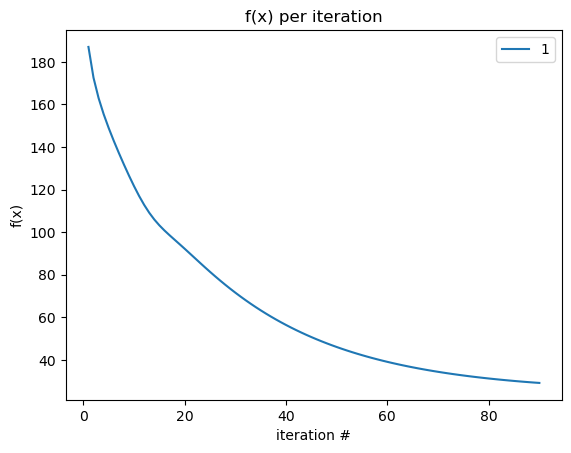

In [369]:
pd.DataFrame(zip(iter_nums, fx_vec)).set_index(0).plot()
plt.xlabel('iteration #'); plt.ylabel(f"f(x)")
plt.title(f"f(x) per iteration")
plt.show()

##### c) Comment on the convergence speed of the algorithm.

#### Question 2
- Reference: Section 11.3 [Barrier Method] - Page 568
- 

In [410]:
def f(x1, x2):
    return (x1 - 1)**2 + 2*(x2 - 2)**2
def cons1(x1, x2):
    return 1 - x1**2 - x2**2
def cons2(x1, x2):
    return x1 + x2

##### (a) Plot the contour of f(¯x) and the feasible set on one single figure, i.e., overlay the feasible set on the contour plot of f(¯x)
- [matplotlib.pyplot.contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html)

In [420]:
x1 = np.linspace(-5, 5, 50)
x2 = x1.reshape(-1,1)
func = f(x1, x2)
constraint1 =  cons1(x1, x2)
constraint2 =  cons2(x1, x2)
#x2 = np.linspace(-1,1, 50)

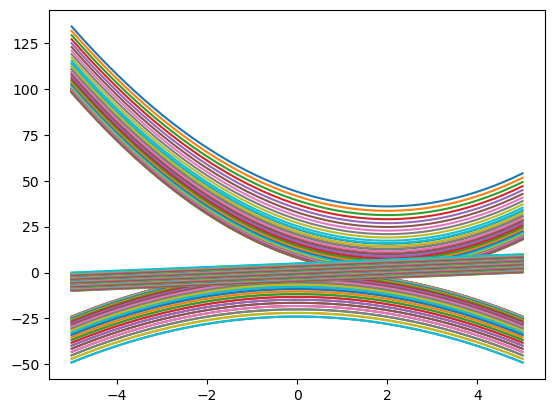

In [421]:
plt.plot(x1, func)
plt.plot(x1, constraint1)
plt.plot(x1, constraint2)
plt.show()

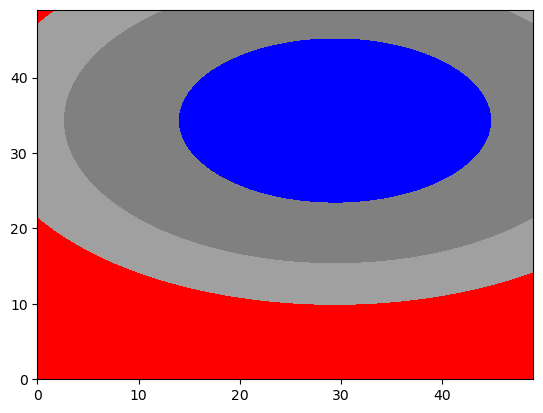

In [422]:
cs = plt.contourf(func, levels=[10, 30, 50],
                  colors=['#808080', '#A0A0A0', '#C0C0C0'], extend='both')
cs.cmap.set_over('red')
cs.cmap.set_under('blue')
cs.changed()

(b) Find a solution to the problem using the natural logarithmic barrier function, i.e., the barrier function is $-\log{h_1(\bar{x}}) − \log{h_2(\bar{x})}$. Use initialization vector $[0.5, 0.5]^T$ and the initial penalty parameter equal to 1 and reduce it by $\frac{1}{2}$ in each iteration. Use a stopping threshold of 0.002

##### (c) In a 2-D figure, plot the trajectory (i.e., the values connected by lines with arrows) of the computed solution vector as the number of iteration progresses.
- matplotlib.pyplot.quiver https://www.statology.org/matplotlib-quiver/

#### Question 3: Collect the stock price for NVDIA (NASDAQ: NVDA) for the past 30 days.

##### (a) Plot the data (date vs. stock price)
- [FinancialData API](https://financialdata.net/documentation)

Python Resources: 
- [1.5. Stochastic Gradient Descent](https://scikit-learn.org/stable/modules/sgd.html)
- [SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#sklearn.linear_model.SGDRegressor)
- [sklearn.pipeline](https://scikit-learn.org/stable/modules/preprocessing.html)

In [16]:
with open('api_keys.json', 'r') as f:
    api_key = json.load(f)['api_key']

In [22]:
# define inputs
ticker = 'NVDA'
end_date = datetime.today().date()
start_date = end_date - pd.Timedelta(days=30)

In [24]:
print(f"Retrieve stock data for {ticker} for timeframe {start_date} to {end_date}")

Retrieve stock data for NVDA for timeframe 2026-03-19 to 2026-04-18


In [54]:
query = f"https://financialdata.net/api/v1/stock-prices?identifier={ticker}&date>={start_date}&date<={end_date}&key={api_key}"
print(query)
response = requests.get(query)
response

In [58]:
data = pd.DataFrame(response.json())
data.to_csv(f"{ticker}_data.csv", index=False)
response.close()

In [98]:
# read in data
data = pd.read_csv(f"{ticker}_data.csv", parse_dates=['date'])
data = data.set_index('date')
data = data.sort_index(ascending=True)
data.index = data.index.date
data = data.loc[start_date : end_date] # 20 days (i.e., trading days), go back further to get 30 days

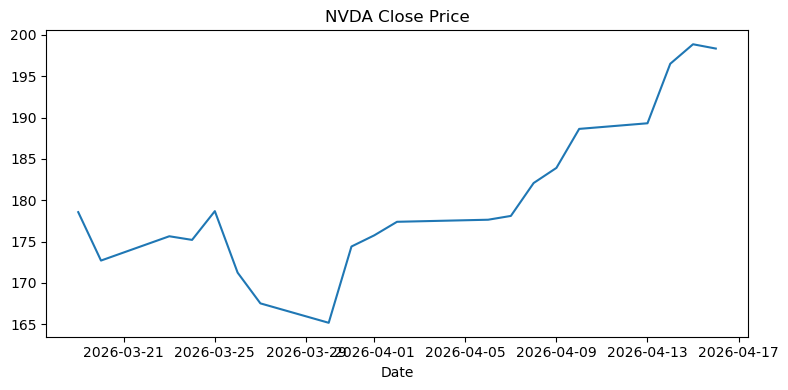

In [120]:
plt.figure(figsize=(8,4))
data['close'].plot()
plt.title(f"{ticker} Close Price")
plt.xlabel('Date');
plt.tight_layout()
plt.show()

##### (b) Implement the stochastic gradient descent algorithm to fit a linear regression model for this data set. Use any required open source libraries. Note that this specific algorithm was not discussed in the class, but all the key ingredients have been covered. So, you must be able to understand how this works.
- from sklearn.linear_model import SGDClassifier
- https://scikit-learn.org/stable/modules/sgd.html

In [176]:
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [177]:
# define hyperparameters
sdg_params = {'max_iter' : 1000, 'loss' : 'squared_error'}
sdg_reg = SGDRegressor(**sdg_params)
pipe = make_pipeline(StandardScaler(), sdg_reg)

In [180]:
pipe.fit(data[data.columns[~data.columns.isin(['close', 'trading_symbol'])]], data['close'])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('sgdregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_r

In [181]:
#y_preds = sdg_reg.predict(data[data.columns[~data.columns.isin(['close', 'trading_symbol'])]])
y_preds = pipe.predict(data[data.columns[~data.columns.isin(['close', 'trading_symbol'])]])

In [182]:
data['y_preds'] = y_preds

##### (c) Plot the raw data and your linear regression model together for visual comparison.
- Show learning curves as SGD approaches the line of best fit

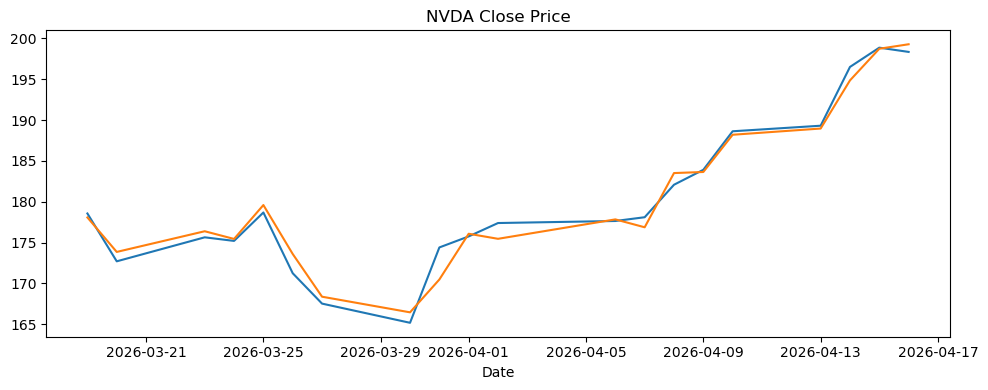

In [183]:
plt.figure(figsize=(10,4))
data['close'].plot()
data['y_preds'].plot()
plt.title(f"{ticker} Close Price")
plt.xlabel('Date');
plt.tight_layout()
plt.show()

##### (d) What does your model predict for NVDIA’s stock price for the next three months into the future?
- Call predict on the method

In [191]:
future_range = pd.bdate_range(end_date, end_date + pd.Timedelta(days=90)).date

In [209]:
#future_date_indexes = np.array([i for i, dt in enumerate(future_range)])

In [207]:
#pipe.predict(future_date_indexes.reshape(-1,1))

##### (e) Explain the pros and cons of gradient descent and stochastic gradient descent.
- Pros: less overhead as each iteration simply uses one data point (randomly selected) to compute the gradient before stepping to the next iteration. 
- Cons: can be more volatile and could miss a global minimum. More dependent on starting initial guess.

#### Question 4
- Reference: Chapter 5 [ Lagrangian, Duality]

In [29]:
def f(x):
    return x**2 + 1

In [31]:
#cons = [(x − 2)(x − 4) ≤ 1]

##### (a) Write the Lagrangian, and plot it for different values of λ ≥ 0
- lagrange — SciPy

##### (b) Write the dual function and then write the dual problem. Plot the dual function. (You must identify which is which. Do not just write equations without words attached to it.)

##### (c) Solve the primal problem.

##### (d) Solve the dual problem.

##### (e) What is the duality gap?